裂縫固定水平線, time-dependent heat equation, u = (x^2+y^2)*phi, f = - 6*phi.

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc
rc('animation', html='jshtml')

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X_MIN, X_MAX = -1.0, 1.0
Y_MIN, Y_MAX = -1.0, 1.0
T_MIN, T_MAX = 0.0, 0.25

N_b_outer = 20
N_f = 4 * N_b_outer
N_b_crack = N_b_outer
N_tip = N_b_outer
N_ic = N_b_outer
epochs_LM = 3000
max_trial = 1
lam = 10000
lam_up, lam_down = 3.0, 0.7

class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList()

        for i in range(len(layers) - 1):
            # ⭐ 最後一層不加 bias
            if i == len(layers) - 2:
                self.layers.append(
                    nn.Linear(layers[i], layers[i+1], bias=False)
                )
            else:
                self.layers.append(
                    nn.Linear(layers[i], layers[i+1], bias=True)
                )

        self.act = torch.tanh

        # initialization
        for m in self.layers:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:   # ⭐ 很重要
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        for l in self.layers[:-1]:
            x = self.act(l(x))
        return self.layers[-1](x)

layers = [4, 30, 1]
model = MLP(layers).to(device)

Device: cpu


In [ ]:
# sampling
def sample_collocation(N):
    x = torch.rand(N*2,1) * (X_MAX - X_MIN) + X_MIN
    y = torch.rand(N*2,1) * (Y_MAX - Y_MIN) + Y_MIN
    t = torch.rand(N*2,1) * (T_MAX - T_MIN) + T_MIN
    # 點到 y=0 的距離 : |y|
    dist_to_crack = torch.abs(y)
    # mask
    mask_crack = (dist_to_crack < 1e-8)
    x, y, t = x[~mask_crack][:N], y[~mask_crack][:N], t[~mask_crack][:N]
    return x.to(device), y.to(device), t.to(device)



def sample_outer_boundary(N_b):
    # 左邊
    x_left = torch.ones(N_b, 1) * X_MIN
    y_left = torch.linspace(Y_MIN, Y_MAX, N_b).unsqueeze(1)
    # 右邊
    x_right = torch.ones(N_b, 1) * X_MAX
    y_right = torch.linspace(Y_MIN, Y_MAX, N_b).unsqueeze(1)
    # 下邊
    y_bottom = torch.ones(N_b, 1) * Y_MIN
    x_bottom = torch.linspace(X_MIN, X_MAX, N_b).unsqueeze(1)
    # 上邊
    y_top = torch.ones(N_b, 1) * Y_MAX
    x_top = torch.linspace(X_MIN, X_MAX, N_b).unsqueeze(1)

    # 合併
    x_all = torch.cat([x_left, x_right, x_bottom, x_top], dim=0)
    y_all = torch.cat([y_left, y_right, y_bottom, y_top], dim=0)
    t_all = torch.rand_like(x_all) * (T_MAX - T_MIN) + T_MIN

    return x_all.to(device), y_all.to(device), t_all.to(device)


def sample_crack_boundary(N):
    t = torch.rand(N, 1, device=device, dtype=torch.float64) * (T_MAX - T_MIN) + T_MIN
    x_vals = torch.linspace(0, 1, N, device=device, dtype=torch.float64).unsqueeze(1)
    y_vals = x_vals * 0.0
    return x_vals, y_vals, t

def sampling_points(N_f, N_b_crack, N_b_outer):
    x_f, y_f, t_f = sample_collocation(N_f)
    x_b_out, y_b_out, t_b_out = sample_outer_boundary(N_b_outer)
    x_b_crack, y_b_crack, t_b_crack = sample_crack_boundary(N_b_crack)

    x_f = x_f.view(-1,1); y_f = y_f.view(-1,1); t_f = t_f.view(-1,1)
    x_b_out = x_b_out.view(-1,1); y_b_out = y_b_out.view(-1,1); t_b_out = t_b_out.view(-1,1)
    x_b_crack = x_b_crack.view(-1,1); y_b_crack = y_b_crack.view(-1,1); t_b_crack = t_b_crack.view(-1,1)

    x_b = torch.cat([x_b_out, x_b_crack], dim=0)
    y_b = torch.cat([y_b_out, y_b_crack], dim=0)
    t_b = torch.cat([t_b_out, t_b_crack], dim=0)

    phi_b, _, _, g_b = compute_phi_and_derivs(x_b, y_b, t_b)
    inp_bc = torch.cat([x_b, y_b, phi_b, t_b], dim=1)

    return x_f, y_f, t_f, x_b_out, y_b_out, t_b_out, x_b_crack, y_b_crack, t_b_crack, inp_bc, g_b

def sample_tip_and_crack(N_tip, N_b_crack):
    # crack 上（不含 tip）
    x_c = torch.linspace(1e-4, 1.0, N_b_crack, device=device).unsqueeze(1)
    y_c = torch.zeros_like(x_c)
    t_c = torch.rand(N_b_crack, 1, device=device) * (T_MAX - T_MIN)

    # tip neighborhood: small disk around (0,0)
    theta = torch.linspace(0, 2*np.pi, N_tip)
    r = 1e-3 * torch.ones_like(theta)
    x_t = (r * torch.cos(theta)).view(-1,1)
    y_t = (r * torch.sin(theta)).view(-1,1)
    t_t = torch.rand(N_tip, 1, device=device) * (T_MAX - T_MIN)

    return x_c, y_c, t_c, x_t, y_t, t_t

def sample_ic(N_ic):
    x = torch.rand(N_ic, 1) * (X_MAX - X_MIN) + X_MIN
    y = torch.rand(N_ic, 1) * (Y_MAX - Y_MIN) + Y_MIN
    t = torch.zeros_like(x)  # t = 0

    # 避開 crack
    mask = torch.abs(y) < 1e-8
    x = x[~mask][:N_ic]
    y = y[~mask][:N_ic]
    t = t[~mask][:N_ic]

    x = x.view(-1,1).to(device)
    y = y.view(-1,1).to(device)
    t = t.view(-1,1).to(device)

    phi, _, _, u_true = compute_phi_and_derivs(x, y, t)
    inp_ic = torch.cat([x, y, phi, t], dim=1)

    return inp_ic, u_true

In [ ]:
def compute_phi(x, y, t):
    x = x.view(-1,1).to(device)
    y = y.view(-1,1).to(device)
    t = t.view(-1,1).to(device)
    angle = torch.tensor(np.pi * 0.0 / 4.0, dtype=x.dtype, device=x.device)
    r = torch.sqrt(torch.clamp(x**2 + y**2, min=1e-12))
    inside = r - (x * torch.cos(angle) + y * torch.sin(angle))
    u_true = (x**2 + y**2)  * torch.sqrt( 0.5 * inside)
    return torch.sqrt( 0.5 * inside), u_true

def compute_phi_and_derivs(x, y, t):
    x = x.view(-1, 1).to(device)
    y = y.view(-1, 1).to(device)
    t = t.view(-1, 1).to(device)
    angle = torch.tensor(np.pi * 0.0 / 4.0, dtype=x.dtype, device=x.device)
    r = torch.sqrt(torch.clamp(x**2 + y**2, min=1e-12))
    inside = r - (x * torch.cos(angle) + y * torch.sin(angle))
    phi = torch.sqrt(0.5 * inside)
    sqrt_term = torch.sqrt(inside)
    phi_x = (torch.sqrt(torch.tensor(2.0, dtype=torch.float64)) *
             (x / r - torch.cos(angle))) / (4.0 * sqrt_term)
    phi_y = (torch.sqrt(torch.tensor(2.0, dtype=torch.float64)) *
             (y / r - torch.sin(angle))) / (4.0 * sqrt_term)
    u_true = (x**2 + y**2)  * phi

    return phi, phi_x, phi_y, u_true

def partials_U_wrt_inputs(model, x, y, phi, t):
    x = x.view(-1,1)
    y = y.view(-1,1)
    phi = phi.view(-1,1)
    t = t.view(-1,1)

    inp = torch.cat([x, y, phi, t], dim=1).to(device)
    inp.requires_grad_(True)
    U = model(inp)  # (N,1)

    grads = torch.autograd.grad(U, inp, grad_outputs=torch.ones_like(U),
                                create_graph=True, retain_graph=True)[0]  # (N,4)
    U_x = grads[:,0:1]
    U_y = grads[:,1:2]
    U_z = grads[:,2:3]
    U_t = grads[:,3:4]
    return U, inp, U_x, U_y, U_z, U_t

def second_partials_U(model, inp, U_x, U_y, U_z):
    grad_Ux = torch.autograd.grad(U_x, inp, grad_outputs=torch.ones_like(U_x),
                                  create_graph=True, retain_graph=True)[0]
    grad_Uy = torch.autograd.grad(U_y, inp, grad_outputs=torch.ones_like(U_y),
                                  create_graph=True, retain_graph=True)[0]
    grad_Uz = torch.autograd.grad(U_z, inp, grad_outputs=torch.ones_like(U_z),
                                  create_graph=True, retain_graph=True)[0]

    U_xx = grad_Ux[:,0:1]
    U_xz = grad_Ux[:,2:3]
    U_yy = grad_Uy[:,1:2]
    U_yz = grad_Uy[:,2:3]
    U_zz = grad_Uz[:,2:3]

    return U_xx, U_yy, U_xz, U_yz, U_zz


def compute_residual_time(model, x, y, t):
    x = x.clone().detach().requires_grad_(True).to(device)
    y = y.clone().detach().requires_grad_(True).to(device)
    t = t.clone().detach().requires_grad_(True).to(device)

    phi, phi_x, phi_y, _ = compute_phi_and_derivs(x, y, t)
    U, inp, U_x, U_y, U_z, U_t = partials_U_wrt_inputs(model, x, y, phi, t)
    U_xx, U_yy, U_xz, U_yz, U_zz = second_partials_U(model, inp, U_x, U_y, U_z)

    r = torch.sqrt(torch.clamp(x**2 + y**2, min=1e-12))
    laplace_U = U_xx + U_yy
    lap = laplace_U + 2.0 * (U_xz * phi_x + U_yz * phi_y) + (1/(4*r)) * U_zz
    ut =  U_t
    residual = ut - lap + 6.0 * phi
    return residual, U, U_zz, U_xz, U_yz


def get_flat_params(model):
    return torch.cat([p.view(-1) for p in model.parameters()])

def compute_jacobian(r, model):
    r = r.view(-1) 
    n_res = r.numel()
    theta = get_flat_params(model)
    n_param = theta.numel()

    J = torch.zeros(n_res, n_param, device=device)

    for i in range(n_res):
        grads = torch.autograd.grad(
            r[i],
            model.parameters(),
            retain_graph=True,
            create_graph=False
        )
        J[i, :] = torch.cat([g.reshape(-1) for g in grads])

    return J

def lm_step_adaptive_time(
    model, data, lam, lam_up, lam_down, max_trial
):
    params = list(model.parameters())
    theta0 = [p.data.clone() for p in params]

    # residual & loss
    r0 = residual_vector_time(model, data)
    loss0 = 0.5 * torch.sum(r0**2)

    # Jacobian & LM system
    J = compute_jacobian(r0, model)
    A = J.T @ J + lam * torch.eye(J.shape[1], device=device)
    g = J.T @ r0.detach()
    m_J, n_J = J.shape

    delta = torch.linalg.solve(A, -g)

    for _ in range(max_trial):
        # trial update
        idx = 0
        for p, p0 in zip(params, theta0):
            n = p.numel()
            p.data = p0 + delta[idx:idx+n].view_as(p)
            idx += n

        r1 = residual_vector_time(model, data)
        loss1 = 0.5 * torch.sum(r1**2)

        if loss1 < loss0:
            lam = max(lam * lam_down, 1e-9)
            res = torch.sqrt(2 * loss1).item()
            return lam, True, res, m_J, n_J
        else:
            # rollback
            for p, p0 in zip(params, theta0):
                p.data = p0
            lam = min(lam * lam_up, 1e8)

    res = torch.sqrt(2 * loss0).item()
    return lam, False, res, m_J, n_J


def sample_all_time_dep(N_f, N_b_crack, N_b_outer, N_ic):
    x_f, y_f, t_f, \
    x_b_out, y_b_out, t_b_out, \
    x_b_crack, y_b_crack, t_b_crack, \
    inp_bc, g_b = sampling_points(N_f, N_b_crack, N_b_outer)

    x_c, y_c, t_c, x_t, y_t, t_t = sample_tip_and_crack(N_tip, N_b_crack=N_b_crack)

    inp_ic, g_ic = sample_ic(N_ic)

    data = {
        "x_f": x_f,
        "y_f": y_f,
        "t_f": t_f,

        "inp_bc": inp_bc,
        "g_b": g_b,

        "x_crack": x_c,
        "y_crack": y_c,
        "t_crack": t_c,

        "x_tip": x_t,
        "y_tip": y_t,
        "t_tip": t_t,

        # IC
        "inp_ic": inp_ic,
        "g_ic": g_ic
    }

    return data


def residual_vector_time(model, data):
    # PDE residual
    r_f, _, _, _, _ = compute_residual_time(
        model,
        data["x_f"],
        data["y_f"],
        data["t_f"]
    )
    r_f = r_f.view(-1)

    # Boundary condition
    r_bc = model(data["inp_bc"]) - data["g_b"]
    r_bc = r_bc.view(-1)
    # crack 上的 ∇_x U_z = 0
    _, _, _, U_xz_c, U_yz_c = compute_residual_time(
        model,
        data["x_crack"],
        data["y_crack"],
        data["t_crack"]
    )

    r_gradUz = torch.cat([
        U_xz_c.view(-1),
        U_yz_c.view(-1)
    ], dim=0) # 有這項loss下不去

    # tip 上的 U_zz = 0
    _, _, U_zz_t, _, _ = compute_residual_time(
        model,
        data["x_tip"],
        data["y_tip"],
        data["t_tip"]
    )

    r_tip = U_zz_t.view(-1)

    # -------- Initial condition --------
    r_ic = model(data["inp_ic"]) - data["g_ic"]
    r_ic = r_ic.view(-1)

    # -------- total residual --------
    r = torch.cat([
        r_f,
        r_bc,
        r_ic,      # ← 新增
        r_tip
    ], dim=0)
    return r


In [30]:
data = sample_all_time_dep(N_f, N_b_crack, N_b_outer, N_ic)


res_hist = []
loss_history_LM = []
lam = 1e-3

print("Start LM training (time-dependent)")

for it in range(epochs_LM):
    lam, ok, res, m_J, n_J = lm_step_adaptive_time(
        model, data, lam, lam_up, lam_down, max_trial=1
    )
    loss = res**2
    res_hist.append(res)
    loss_history_LM.append(loss)
    epochs_LM = np.arange(len(loss_history_LM))
    status = "✓" if ok else "✗"

    if it % 10 == 0:
        print(f"iter {it:04d} | loss = {loss:.3e} | λ = {lam:.1e} | {status}")

print("Training finished.")



Start LM training (time-dependent)
iter 0000 | loss = 1.485e+03 | λ = 3.0e-03 | ✗
iter 0010 | loss = 3.769e+02 | λ = 5.3e-01 | ✓
iter 0020 | loss = 1.200e+00 | λ = 1.2e+00 | ✓
iter 0030 | loss = 4.130e-02 | λ = 3.3e-02 | ✓
iter 0040 | loss = 1.983e-03 | λ = 1.7e-02 | ✓
iter 0050 | loss = 9.849e-04 | λ = 8.9e-03 | ✓
iter 0060 | loss = 5.440e-04 | λ = 4.6e-03 | ✓
iter 0070 | loss = 2.892e-04 | λ = 2.4e-03 | ✓
iter 0080 | loss = 1.970e-04 | λ = 5.3e-03 | ✗
iter 0090 | loss = 1.307e-04 | λ = 2.8e-03 | ✓
iter 0100 | loss = 9.965e-05 | λ = 1.4e-03 | ✓
iter 0110 | loss = 8.472e-05 | λ = 3.2e-03 | ✗
iter 0120 | loss = 6.838e-05 | λ = 1.7e-03 | ✓
iter 0130 | loss = 5.678e-05 | λ = 8.6e-04 | ✓
iter 0140 | loss = 4.838e-05 | λ = 1.9e-03 | ✗
iter 0150 | loss = 3.916e-05 | λ = 9.9e-04 | ✓
iter 0160 | loss = 3.170e-05 | λ = 5.1e-04 | ✓
iter 0170 | loss = 2.673e-05 | λ = 1.1e-03 | ✗
iter 0180 | loss = 2.283e-05 | λ = 5.9e-04 | ✓
iter 0190 | loss = 2.016e-05 | λ = 3.1e-04 | ✓
iter 0200 | loss = 1.760e

In [31]:
n_theta = sum(p.numel() for p in model.parameters())
print(n_theta)
print(m_J)
print(n_J)

180
220
180


Relative L2 error: 3.3182244139929364e-05
Relative Infinity norm error: 4.976132666420556e-05


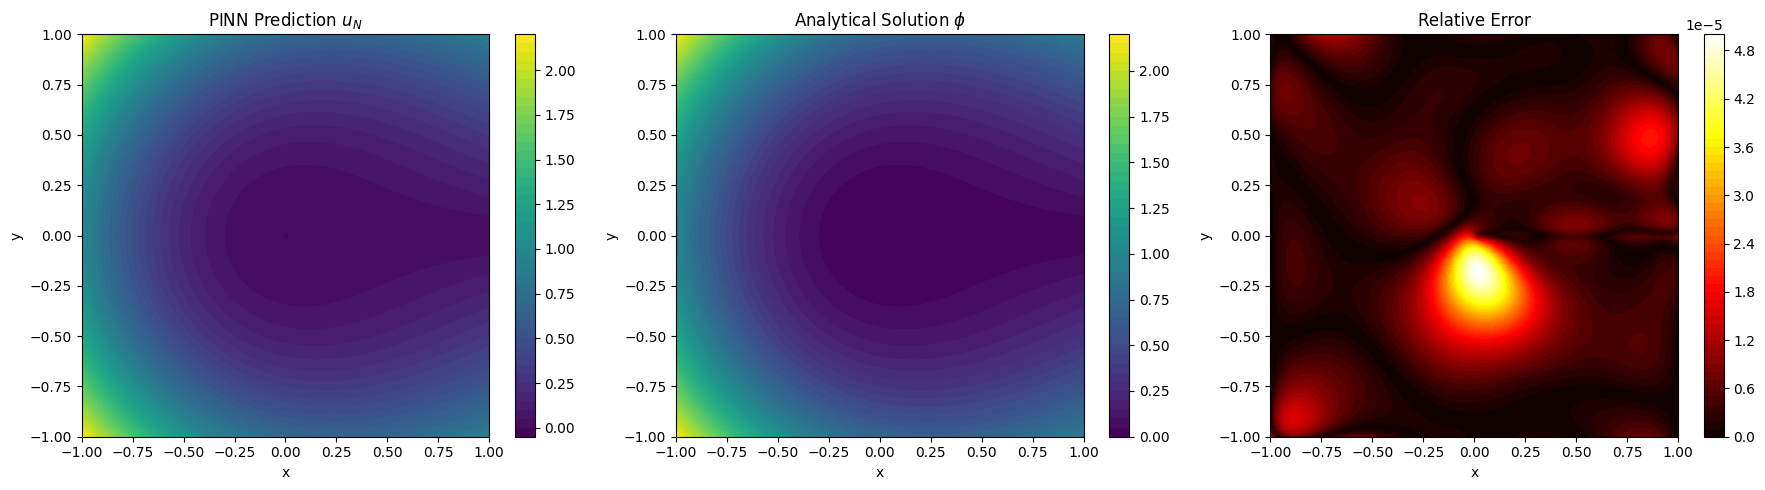

In [32]:
# test
t0 = 0.05
nx = 100
xs = np.linspace(X_MIN, X_MAX, nx)
ys = np.linspace(Y_MIN, Y_MAX, nx)
Xg, Yg = np.meshgrid(xs, ys)

x_grid = torch.from_numpy(Xg.flatten()[:,None]).to(device).double()
y_grid = torch.from_numpy(Yg.flatten()[:,None]).to(device).double()
t_grid = torch.full_like(x_grid, t0).to(device)  # 全部時間都固定為 t0

with torch.no_grad():
    phi_grid, u_true_grid = compute_phi(x_grid, y_grid, t_grid)

# 預測 u
with torch.no_grad():
    inp_grid = torch.cat([x_grid, y_grid, phi_grid, t_grid], dim=1)
    u_pred = model(inp_grid)
    u_pred = u_pred.cpu().numpy().reshape(nx, nx)
    u_true_grid = u_true_grid.cpu().numpy().reshape(nx, nx)

# 逐點相對誤差
u_true_norm = np.max(np.abs(u_true_grid))   # 真實解的 inf norm
error_rel = np.abs(u_pred - u_true_grid) / (u_true_norm)
# 整體相對誤差
diff = torch.from_numpy(np.abs(u_pred - u_true_grid)).double()
u_ext_2_norm = torch.from_numpy(np.abs(u_true_grid)).double()
error_1 = torch.norm(diff) / torch.norm(u_ext_2_norm)
error_2 = torch.norm(diff, p=float('inf')) / u_true_norm  
print("Relative L2 error:", error_1.item())
print("Relative Infinity norm error:", error_2.item())
# 畫圖
fig, axs = plt.subplots(1, 3, figsize=(18,5))

im0 = axs[0].contourf(Xg, Yg, u_pred, 50, cmap='viridis')
fig.colorbar(im0, ax=axs[0])
axs[0].set_title('PINN Prediction $u_N$')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

im1 = axs[1].contourf(Xg, Yg, u_true_grid, 50, cmap='viridis')
fig.colorbar(im1, ax=axs[1])
axs[1].set_title('Analytical Solution $\\phi$')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')

im2 = axs[2].contourf(Xg, Yg, error_rel, 50, cmap='hot')
fig.colorbar(im2, ax=axs[2])
axs[2].set_title('Relative Error')
axs[2].set_xlabel('x')
axs[2].set_ylabel('y')

plt.tight_layout()
plt.show()


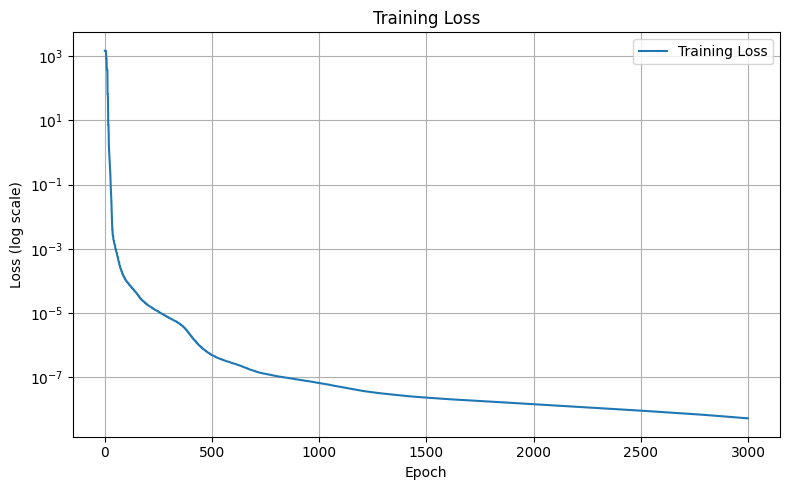

In [33]:
# loss
epochs_arr = np.arange(len(loss_history_LM))
plt.figure(figsize=(8,5))
plt.semilogy(epochs_arr, loss_history_LM, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
# Save training loss for plotting later
np.savez(
    "lm_loss.npz",
    epoch=epochs_LM,
    loss=loss_history_LM
)
